# Ticker List Analysis

This notebook uses only ticker CSV files found in `dataset/stocks` and visualizes ticker and data-quality insights from that source.


## Cell 1: Imports
Loads the core Python libraries used throughout the notebook for paths, data frames, and plotting.


In [115]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Cell 2: Analysis Settings
Defines notebook-level parameters used for previews and top/bottom ranking plots.


In [116]:
TOP_N = 20
MAX_PREVIEW_ROWS = 10


## Cell 3: Project Root Helpers
Finds the project root, resolves the `dataset/stocks` source path, and defines small shared table helpers.


In [117]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing dataset/")


def resolve_stocks_dir(project_root: Path) -> Path:
    stocks_dir = project_root / "dataset" / "stocks"
    if not stocks_dir.exists():
        raise FileNotFoundError(f"Required source directory not found: {stocks_dir}")
    return stocks_dir


def load_source_tickers(stocks_dir: Path) -> tuple[list[str], list[Path]]:
    price_paths = sorted(stocks_dir.glob("*.csv"))
    tickers = sorted({path.stem.upper() for path in price_paths})
    return tickers, price_paths


def count_table(series: pd.Series, index_name: str, count_name: str = "count") -> pd.DataFrame:
    return series.value_counts().rename_axis(index_name).to_frame(count_name)


PROJECT_ROOT = find_project_root(Path.cwd())
print(f"Project root: {PROJECT_ROOT}")


Project root: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project


## Cell 4: Data Parsing And Metrics Helpers
Defines reusable functions to clean per-ticker CSVs and compute quality/market metrics (rows, returns, volatility, volume).


In [118]:
NUMERIC_COLUMNS = ("Adj Close", "Close", "High", "Low", "Open", "Volume")
STATUS_OK = "ok"
STATUS_EMPTY = "empty"
STATUS_UNPARSED = "unparsed"
RESULT_COLUMNS = [
    "ticker",
    "rows",
    "start_date",
    "end_date",
    "price_start",
    "price_end",
    "total_return_pct",
    "daily_volatility_pct",
    "avg_volume",
]
PREVIEW_COLUMNS = [
    "ticker",
    "status",
    "rows",
    "start_date",
    "end_date",
    "price_start",
    "price_end",
    "total_return_pct",
    "daily_volatility_pct",
    "avg_volume",
]
RANKED_FIGSIZE = (20, 7)


def _base_summary(ticker: str, status: str, rows: int = 0) -> dict:
    return {
        "ticker": ticker,
        "status": status,
        "rows": int(rows),
        "start_date": None,
        "end_date": None,
        "total_return_pct": np.nan,
        "daily_volatility_pct": np.nan,
        "avg_volume": np.nan,
        "price_start": np.nan,
        "price_end": np.nan,
        "price_range": np.nan,
        "range_pct": np.nan,
        "volume_range": np.nan,
        "volume_range_pct": np.nan,
    }


def _series_range_metrics(series: pd.Series) -> tuple[float, float]:
    clean = series.dropna()
    if clean.empty:
        return np.nan, np.nan

    max_val = float(clean.max())
    min_val = float(clean.min())
    value_range = max_val - min_val
    pct = float(value_range / min_val * 100) if min_val > 0 else np.nan
    return value_range, pct


def _pct_change(first: float, last: float) -> float:
    if first in (0.0, -0.0) or not np.isfinite(first) or not np.isfinite(last):
        return np.nan
    return float((last / first - 1.0) * 100)


def _price_span_metrics(high: pd.Series, low: pd.Series) -> tuple[float, float]:
    high_clean = high.dropna()
    low_clean = low.dropna()
    if high_clean.empty or low_clean.empty:
        return np.nan, np.nan

    max_high = float(high_clean.max())
    min_low = float(low_clean.min())
    price_range = max_high - min_low
    range_pct = float(price_range / min_low * 100) if min_low > 0 else np.nan
    return price_range, range_pct


def load_local_price_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.empty:
        return df

    parsed_first_date = pd.to_datetime(df.iloc[0].get("Date"), errors="coerce")
    if pd.isna(parsed_first_date):
        # Some yfinance exports include an extra symbol row after the header.
        df = df.iloc[1:].copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)


def summarize_price_file(path: Path) -> dict:
    ticker = path.stem.upper()
    try:
        df = load_local_price_csv(path)
    except Exception as exc:
        return _base_summary(ticker, f"error: {exc}")

    if df.empty:
        return _base_summary(ticker, STATUS_EMPTY)

    close = df["Close"].dropna() if "Close" in df.columns else pd.Series(dtype=float)
    if close.empty:
        price_start = np.nan
        price_end = np.nan
        total_return_pct = np.nan
        daily_volatility_pct = np.nan
    else:
        price_start = float(close.iloc[0])
        price_end = float(close.iloc[-1])

        if len(close) >= 2:
            # Percent change from first close in the file to last close in the file.
            total_return_pct = _pct_change(price_start, price_end)
            daily_volatility_pct = float(close.pct_change().std() * 100)
        else:
            total_return_pct = np.nan
            daily_volatility_pct = np.nan

    avg_volume = float(df["Volume"].dropna().mean()) if "Volume" in df.columns else np.nan

    if "Volume" in df.columns:
        volume_range, volume_range_pct = _series_range_metrics(df["Volume"])
    else:
        volume_range, volume_range_pct = np.nan, np.nan

    if "High" in df.columns and "Low" in df.columns:
        price_range, range_pct = _price_span_metrics(df["High"], df["Low"])
    else:
        price_range, range_pct = np.nan, np.nan

    summary = _base_summary(ticker, STATUS_OK, rows=len(df))
    summary.update(
        {
            "start_date": df["Date"].min().date(),
            "end_date": df["Date"].max().date(),
            "price_start": price_start,
            "price_end": price_end,
            "total_return_pct": total_return_pct,
            "daily_volatility_pct": daily_volatility_pct,
            "avg_volume": avg_volume,
            "price_range": price_range,
            "range_pct": range_pct,
            "volume_range": volume_range,
            "volume_range_pct": volume_range_pct,
        }
    )
    return summary


def build_quality_frame(paths: list[Path]) -> pd.DataFrame:
    return pd.DataFrame([summarize_price_file(path) for path in paths])


def build_analysis_frame(tickers: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    analysis = tickers.merge(quality, on="ticker", how="left")
    analysis["status"] = analysis["status"].fillna(STATUS_UNPARSED)
    analysis["rows"] = analysis["rows"].fillna(0).astype(int)
    return analysis


def _plot_hist(series: pd.Series, ax, title: str, xlabel: str, color: str, alpha: float = 0.85) -> None:
    series.dropna().plot(kind="hist", bins=30, ax=ax, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel(xlabel)


def _plot_ranked_bars(ax, labels: pd.Series, values: pd.Series, title: str, ylabel: str, color: str) -> None:
    ax.bar(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Ticker")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=70)


def plot_overview_charts(ok_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    _plot_hist(ok_df["rows"], axes[0, 0], "Distribution of Rows per Ticker", "Rows", "#264653")

    returns = ok_df["total_return_pct"].dropna()
    axes[0, 1].set_title("Total Return Distribution (%)")
    axes[0, 1].set_xlabel("Total Return %")
    axes[0, 1].set_ylabel("Frequency")

    if returns.empty:
        axes[0, 1].text(0.5, 0.5, "No total return data", ha="center", va="center", transform=axes[0, 1].transAxes)
    else:
        bins = np.histogram_bin_edges(returns, bins=30)
        counts, edges = np.histogram(returns, bins=bins)
        left_edges = edges[:-1]
        widths = np.diff(edges)
        centers = left_edges + widths / 2

        neg_mask = centers < 0
        pos_mask = ~neg_mask

        if neg_mask.any():
            axes[0, 1].bar(
                left_edges[neg_mask],
                counts[neg_mask],
                width=widths[neg_mask],
                align="edge",
                color="#c1121f",
                alpha=0.8,
                label="Negative",
            )
        if pos_mask.any():
            axes[0, 1].bar(
                left_edges[pos_mask],
                counts[pos_mask],
                width=widths[pos_mask],
                align="edge",
                color="#2a9d8f",
                alpha=0.8,
                label="Positive",
            )

        axes[0, 1].axvline(0, color="#555555", linestyle="--", linewidth=1)
        axes[0, 1].legend()

    _plot_hist(ok_df["daily_volatility_pct"], axes[1, 0], "Daily Volatility Distribution (%)", "Daily Volatility %", "#e9c46a", alpha=0.9)

    avg_volume = ok_df["avg_volume"].dropna()
    positive_volume = avg_volume[avg_volume > 0]

    if positive_volume.empty:
        axes[1, 1].text(0.5, 0.5, "No positive avg volume data", ha="center", va="center", transform=axes[1, 1].transAxes)
    else:
        vmin = float(positive_volume.min())
        vmax = float(positive_volume.max())

        if np.isclose(vmin, vmax):
            bins = np.array([vmin * 0.9, vmax * 1.1])
        else:
            bins = np.logspace(np.log10(vmin), np.log10(vmax), 30)

        axes[1, 1].hist(positive_volume, bins=bins, color="#e76f51", alpha=0.8)
        axes[1, 1].set_xscale("log")

    axes[1, 1].set_title("Average Volume Distribution")
    axes[1, 1].set_xlabel("Average Volume (log scale)")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def plot_top_bottom_movers(ok_df: pd.DataFrame, top_n: int) -> None:
    movers = ok_df[["ticker", "total_return_pct"]].dropna().sort_values("total_return_pct")
    bottom = movers.head(top_n)
    top = movers.tail(top_n)

    fig, axes = plt.subplots(1, 2, figsize=RANKED_FIGSIZE)
    _plot_ranked_bars(
        axes[0],
        bottom["ticker"],
        bottom["total_return_pct"],
        title=f"Bottom {top_n} Tickers by Total Return",
        ylabel="Total Return %",
        color="#c1121f",
    )
    _plot_ranked_bars(
        axes[1],
        top["ticker"],
        top["total_return_pct"],
        title=f"Top {top_n} Tickers by Total Return",
        ylabel="Total Return %",
        color="#2a9d8f",
    )

    plt.tight_layout()
    plt.show()


def plot_all_total_returns(ok_df: pd.DataFrame) -> None:
    all_df = ok_df[["ticker", "total_return_pct"]].dropna().sort_values("total_return_pct", ascending=False).reset_index(drop=True)
    if all_df.empty:
        print("No total return data available for all-ticker plot.")
        return

    x = np.arange(len(all_df))
    colors = np.where(all_df["total_return_pct"] < 0, "#c1121f", "#2a9d8f")

    fig, ax = plt.subplots(figsize=(max(18, len(all_df) * 0.15), 7))
    ax.bar(x, all_df["total_return_pct"], color=colors, width=0.9)
    ax.axhline(0, color="#555555", linestyle="--", linewidth=1)

    step = max(1, len(all_df) // 40)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(all_df["ticker"].iloc[::step], rotation=70)

    ax.set_title("Total Return for All Tickers")
    ax.set_xlabel("Ticker")
    ax.set_ylabel("Total Return %")

    plt.tight_layout()
    plt.show()


def top_return_performers(ok_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    return (
        ok_df[RESULT_COLUMNS]
        .sort_values("total_return_pct", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def worst_return_performers(ok_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    return (
        ok_df[RESULT_COLUMNS]
        .sort_values("total_return_pct", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )


PCT_COLUMNS = ("total_return_pct", "daily_volatility_pct")


def _format_pct(series: pd.Series) -> pd.Series:
    return series.map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")


def format_pct_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in PCT_COLUMNS:
        if col in out.columns:
            out[col] = _format_pct(out[col])
    return out


## Cell 5: Build Analysis Table
Builds the analysis table directly from tickers discovered in `dataset/stocks` and parsed CSV summaries.


In [119]:
STOCKS_DIR = resolve_stocks_dir(PROJECT_ROOT)
TICKERS, price_paths = load_source_tickers(STOCKS_DIR)
ticker_df = pd.DataFrame({"ticker": TICKERS})

quality_df = build_quality_frame(price_paths)
analysis_df = build_analysis_frame(ticker_df, quality_df)

source_summary = pd.Series(
    {
        "source_directory": str(STOCKS_DIR),
        "csv_files_detected": len(price_paths),
        "unique_tickers_detected": len(TICKERS),
    }
)

display(source_summary.to_frame("value"))
display(count_table(analysis_df["status"], "status"))
display(format_pct_columns(analysis_df[PREVIEW_COLUMNS].head(MAX_PREVIEW_ROWS)))


,value
source_directory,/scratch/temp_/NN_Trading_Bot_Private/NN_Tradi...
csv_files_detected,198
unique_tickers_detected,198


,count
status,
ok,198


,ticker,status,rows,start_date,end_date,price_start,price_end,total_return_pct,daily_volatility_pct,avg_volume
0,AA,ok,313,2025-01-02,2026-04-02,37.990002,71.529999,88.29%,3.49%,6.462209e+06
1,AAPL,ok,313,2025-01-02,2026-04-02,243.850006,255.919998,4.95%,1.95%,5.285701e+07
2,ABEV,ok,313,2025-01-02,2026-04-02,1.830000,2.930000,60.11%,1.79%,3.298768e+07
3,ACI,ok,313,2025-01-02,2026-04-02,19.660000,17.450001,-11.24%,1.87%,6.859551e+06
4,ADSK,ok,313,2025-01-02,2026-04-02,293.320007,238.080002,-18.83%,1.91%,1.692732e+06
5,AFRM,ok,313,2025-01-02,2026-04-02,62.509998,46.310001,-25.92%,4.58%,6.857327e+06
6,AGNC,ok,313,2025-01-02,2026-04-02,9.280000,10.150000,9.37%,1.40%,2.326168e+07
7,ALB,ok,313,2025-01-02,2026-04-02,85.230003,178.089996,108.95%,3.87%,3.401514e+06
8,ALGN,ok,313,2025-01-02,2026-04-02,208.490005,170.600006,-18.17%,3.22%,1.257930e+06
9,AMN,ok,313,2025-01-02,2026-04-02,24.549999,18.200001,-25.87%,3.63%,1.008944e+06


## Cell 6: Final Visual Analytics
Builds overview charts, top/bottom movers, and displays strongest tickers by return from valid source-folder data.


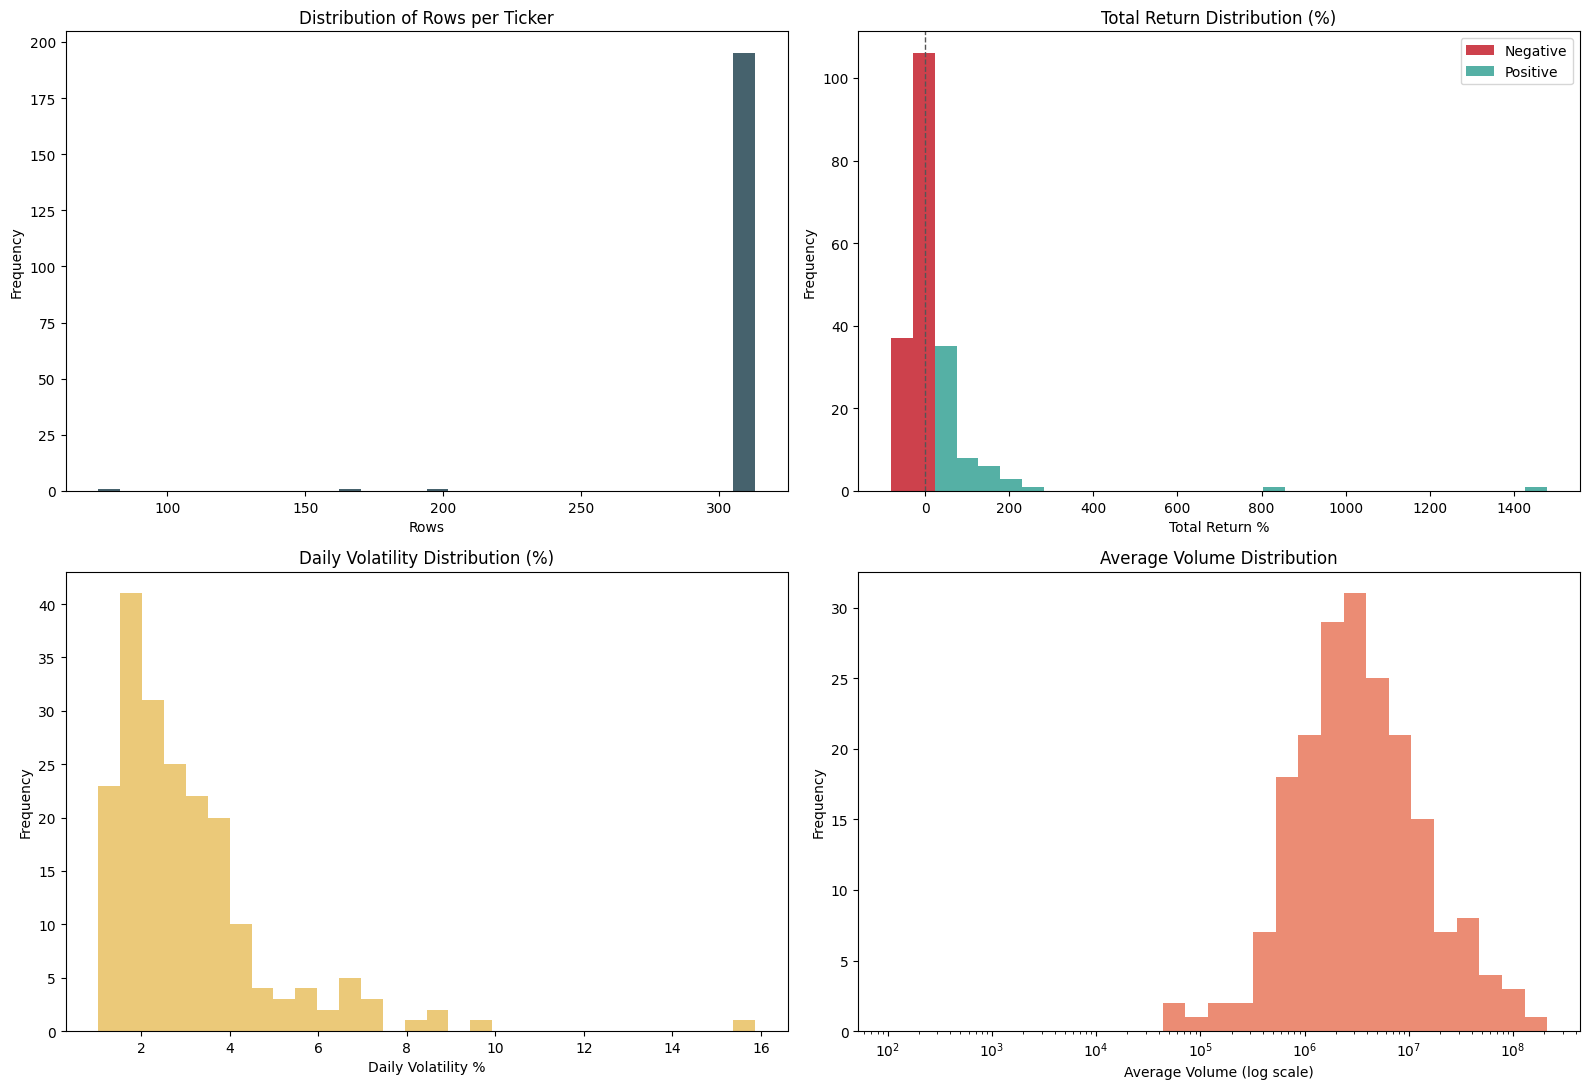

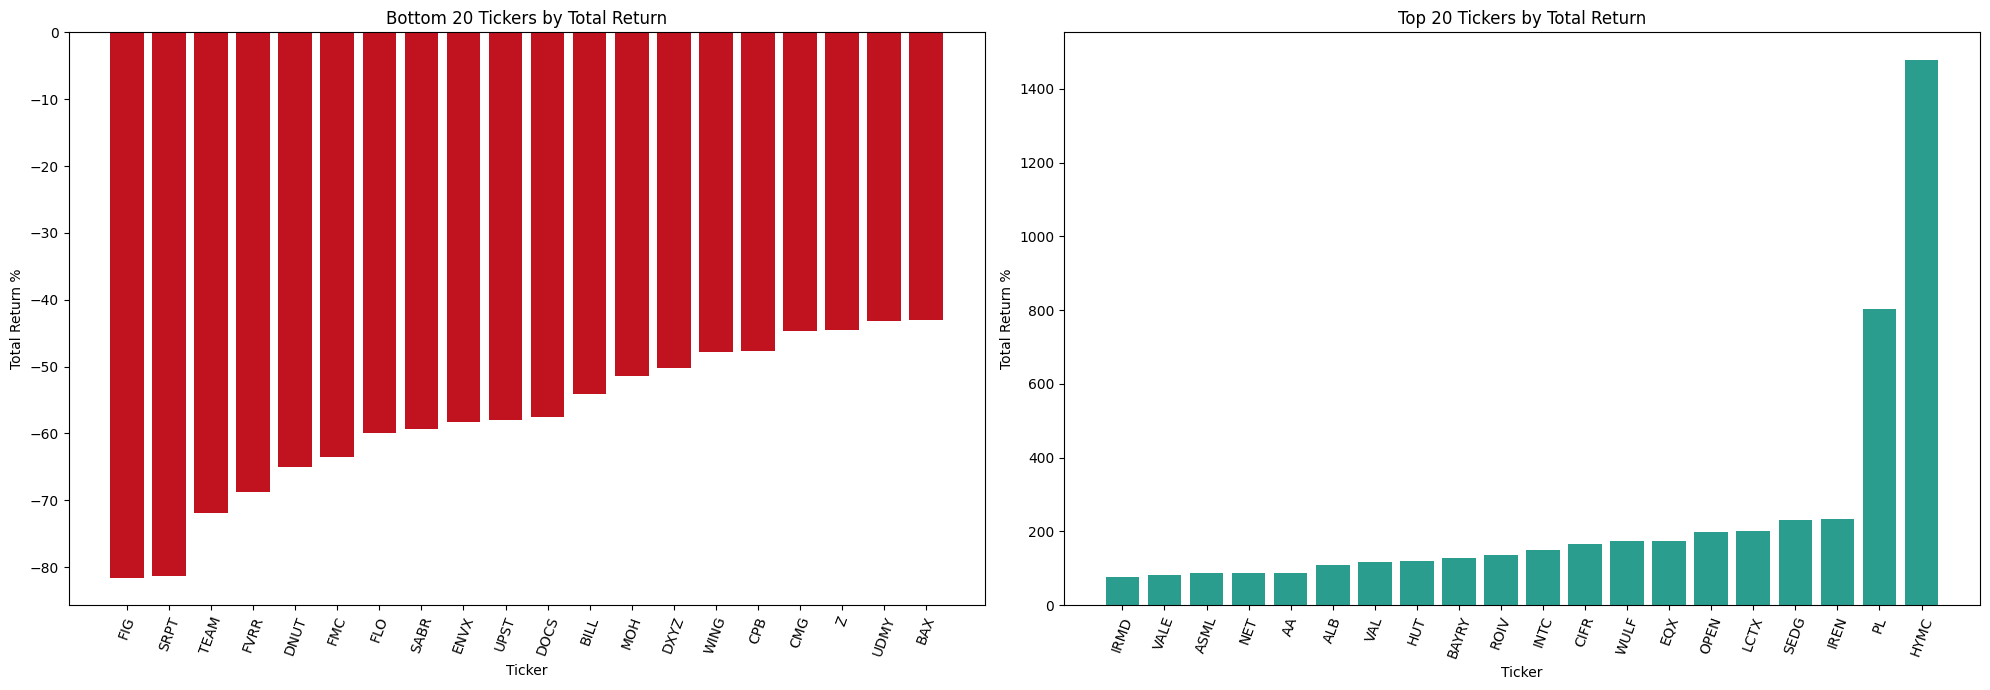

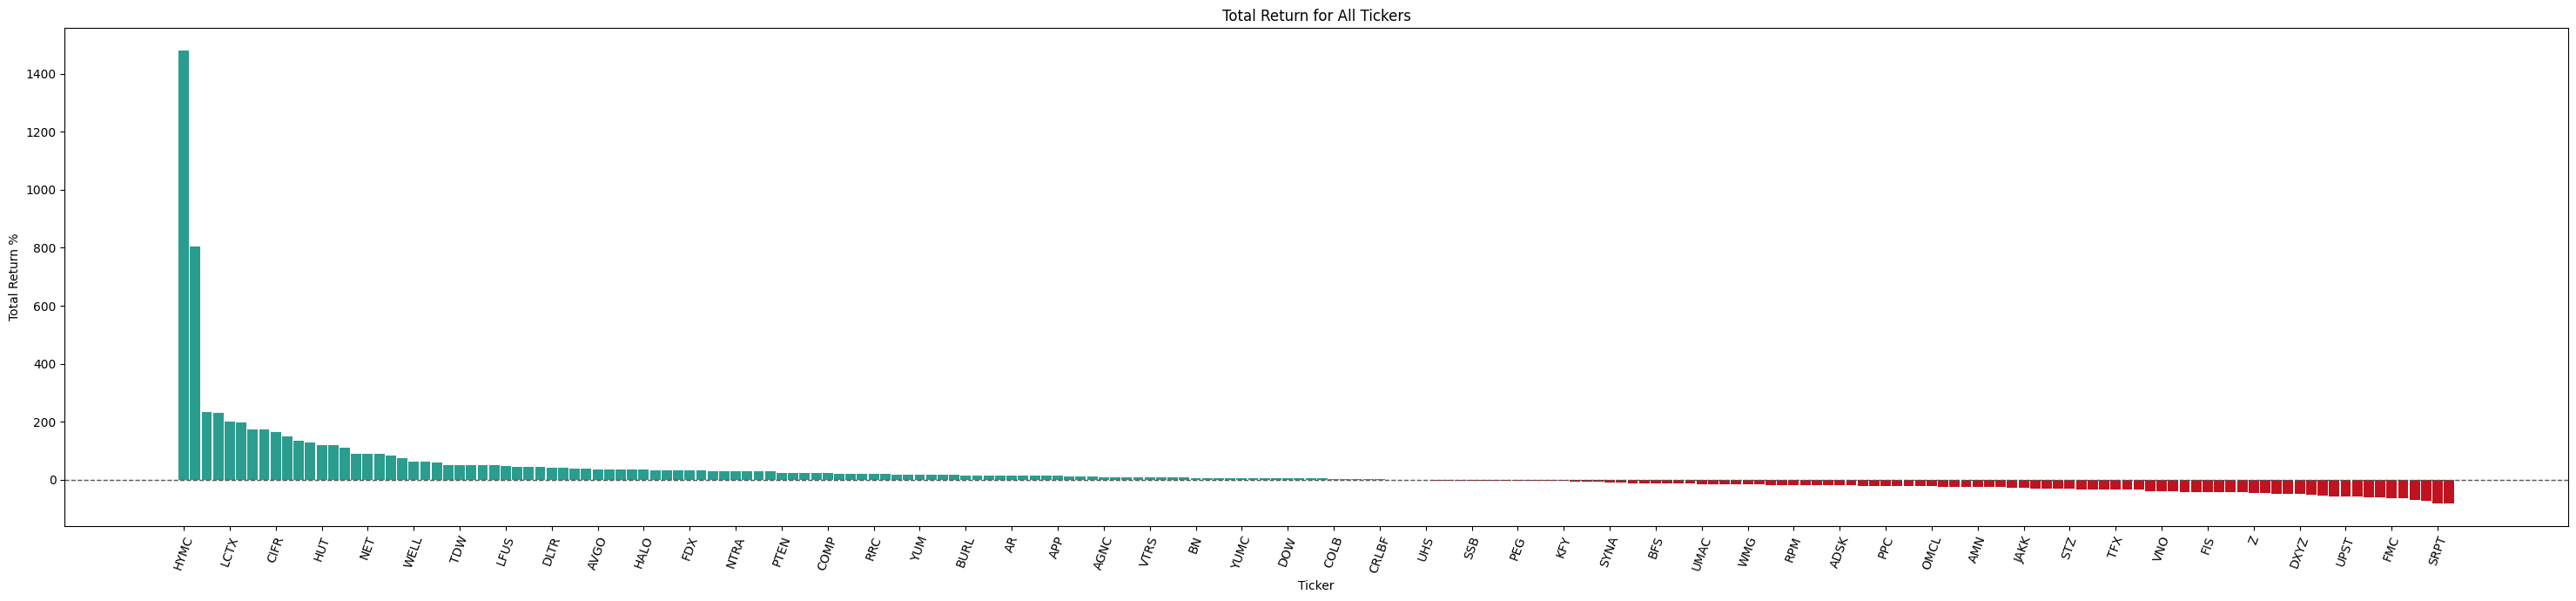

Top 20 performers by total return


,ticker,rows,start_date,end_date,price_start,price_end,total_return_pct,daily_volatility_pct,avg_volume
0,HYMC,313,2025-01-02,2026-04-02,2.280000,36.009998,1479.39%,7.06%,1.773500e+06
1,PL,313,2025-01-02,2026-04-02,3.970000,35.880001,803.78%,6.67%,9.905048e+06
2,IREN,313,2025-01-02,2026-04-02,10.460000,34.770000,232.41%,6.31%,2.871741e+07
3,SEDG,313,2025-01-02,2026-04-02,14.800000,48.750000,229.39%,6.62%,4.264895e+06
4,LCTX,313,2025-01-02,2026-04-02,0.520000,1.570000,201.92%,4.98%,1.708231e+06
5,OPEN,313,2025-01-02,2026-04-02,1.590000,4.740000,198.11%,9.61%,1.252475e+08
6,EQX,313,2025-01-02,2026-04-02,5.310000,14.590000,174.76%,3.66%,1.221347e+07
7,WULF,313,2025-01-02,2026-04-02,5.460000,14.880000,172.53%,7.27%,4.101724e+07
8,CIFR,313,2025-01-02,2026-04-02,4.830000,12.820000,165.42%,7.10%,2.973209e+07
9,INTC,313,2025-01-02,2026-04-02,20.219999,50.380001,149.16%,4.24%,1.013950e+08


Worst 20 performers by total return


,ticker,rows,start_date,end_date,price_start,price_end,total_return_pct,daily_volatility_pct,avg_volume
0,FIG,170,2025-07-31,2026-04-02,115.500000,21.270000,-81.58%,5.52%,1.175667e+07
1,SRPT,313,2025-01-02,2026-04-02,124.089996,23.230000,-81.28%,6.54%,5.330452e+06
2,TEAM,313,2025-01-02,2026-04-02,242.389999,68.290001,-71.83%,3.38%,3.236603e+06
3,FVRR,313,2025-01-02,2026-04-02,32.040001,10.030000,-68.70%,2.97%,8.697380e+05
4,DNUT,313,2025-01-02,2026-04-02,9.730000,3.400000,-65.06%,4.94%,5.128724e+06
5,FMC,313,2025-01-02,2026-04-02,48.740002,17.750000,-63.58%,4.42%,3.366079e+06
6,FLO,313,2025-01-02,2026-04-02,20.549999,8.240000,-59.90%,1.87%,3.465179e+06
7,SABR,313,2025-01-02,2026-04-02,3.570000,1.450000,-59.38%,5.77%,6.961171e+06
8,ENVX,313,2025-01-02,2026-04-02,12.110000,5.060000,-58.22%,5.39%,6.738052e+06
9,UPST,313,2025-01-02,2026-04-02,60.799999,25.580000,-57.93%,5.10%,6.135284e+06


In [120]:
ok_df = analysis_df.loc[analysis_df["status"] == STATUS_OK].copy()

if ok_df.empty:
    print("No valid CSV data available for plotting from the source folder yet.")
else:
    plot_overview_charts(ok_df)

    plot_top_bottom_movers(ok_df, TOP_N)
    plot_all_total_returns(ok_df)

    print(f"Top {TOP_N} performers by total return")
    display(format_pct_columns(top_return_performers(ok_df, TOP_N)))

    print(f"Worst {TOP_N} performers by total return")
    display(format_pct_columns(worst_return_performers(ok_df, TOP_N)))
